# GNN Spam Detection

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

c:\Users\kevin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0+cpu
CUDA available: False
Device: cpu


## 1. Load & Preprocess

In [2]:
df = pd.read_csv('yelpzip.csv', index_col=0)
df['label'] = df['label'].map({-1: 1, 1: 0})
df['date'] = pd.to_datetime(df['date'])

# global stats (for node features)
user_review_cnt = df.groupby('user_id').size()
prod_review_cnt = df.groupby('prod_id').size()

print(f"Total: {len(df):,} reviews | Spam ratio: {df['label'].mean():.2%}")
df.head(3)

Total: 608,458 reviews | Spam ratio: 13.22%


,user_id,prod_id,rating,label,date,text,tag
0,5044,0,1.0,1,2014-11-16,"Drinks were bad, the hot chocolate was watered...",fake
1,5045,0,1.0,1,2014-09-08,This was the worst experience I've ever had a ...,fake
2,5046,0,3.0,1,2013-10-06,This is located on the site of the old Spruce ...,fake


In [21]:
from itertools import combinations

# ── 공통 함수 ──────────────────────────────────────────

def build_edges(df, group_col, max_per_group=30):
    src, dst = [], []
    for _, grp in df.groupby(group_col)['node_id']:
        nodes = grp.tolist()
        if len(nodes) < 2:
            continue
        if len(nodes) > max_per_group:
            nodes = np.random.choice(nodes, max_per_group, replace=False).tolist()
        for u, v in combinations(nodes, 2):
            src += [u, v]; dst += [v, u]
    return src, dst


class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = F.dropout(F.relu(self.conv1(x, ei)), p=self.drop, training=self.training)
        x = F.dropout(F.relu(self.conv2(x, ei)), p=self.drop, training=self.training)
        return self.lin(x)


def run_pipeline(raw_sub, name, epochs=100):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    sub = raw_sub.reset_index(drop=True).copy()
    sub['node_id'] = range(len(sub))
    sub['month']   = sub['date'].dt.month
    sub['user_cnt'] = sub['user_id'].map(user_review_cnt)
    sub['prod_cnt'] = sub['prod_id'].map(prod_review_cnt)
    sub['text_len'] = sub['text'].str.len()
    sub['prod_rating'] = sub['prod_id'].astype(str) + '_' + sub['rating'].astype(str)

    # edges
    np.random.seed(42)
    rur = build_edges(sub, 'user_id')
    rsr = build_edges(sub, 'prod_rating')
    ei  = torch.tensor([rur[0]+rsr[0], rur[1]+rsr[1]], dtype=torch.long)
    print(f"R-U-R: {len(rur[0])//2:,} | R-S-R: {len(rsr[0])//2:,} | Total: {ei.shape[1]//2:,}")

    # features & split
    feature_cols = ['rating', 'user_cnt', 'prod_cnt', 'text_len', 'month']
    X = StandardScaler().fit_transform(sub[feature_cols].values)
    y = sub['label'].values
    idx = np.arange(len(sub))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
    tr_mask = torch.zeros(len(sub), dtype=torch.bool); tr_mask[tr_idx] = True
    te_mask = torch.zeros(len(sub), dtype=torch.bool); te_mask[te_idx] = True

    data = Data(x=torch.tensor(X, dtype=torch.float),
                edge_index=ei,
                y=torch.tensor(y, dtype=torch.long),
                train_mask=tr_mask, test_mask=te_mask).to(DEVICE)
    print(f"Train: {tr_mask.sum():,} | Test: {te_mask.sum():,}")

    # model
    n0, n1 = (y==0).sum(), (y==1).sum()
    cw = torch.tensor([1.0, n0/n1], dtype=torch.float).to(DEVICE)
    model = GCN(in_ch=len(feature_cols)).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    history = {'loss': [], 'pr_auc': [], 'macro_f1': []}

    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad()
        out  = model(data)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=cw)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            prob = F.softmax(model(data), dim=1)[:,1].cpu().numpy()
            pred = model(data).argmax(dim=1).cpu().numpy()
        y_te   = y[te_mask.cpu()]
        pr_auc = average_precision_score(y_te, prob[te_mask.cpu()])
        mf1    = f1_score(y_te, pred[te_mask.cpu()], average='macro', zero_division=0)
        history['loss'].append(loss.item())
        history['pr_auc'].append(pr_auc)
        history['macro_f1'].append(mf1)
        if ep % 10 == 0:
            print(f"Epoch {ep:3d} | Loss {loss.item():.4f} | PR-AUC {pr_auc:.4f} | F1 {mf1:.4f}")

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, color in zip(axes, ['loss','pr_auc','macro_f1'],
                               ['#4C72B0','#55A868','#DD8452']):
        ax.plot(history[key], color=color)
        ax.set_title(key, fontweight='bold'); ax.set_xlabel('Epoch')
    plt.suptitle(name, fontweight='bold'); plt.tight_layout()
    plt.savefig(f'gcn_{name.split()[0].lower()}.png', bbox_inches='tight')
    plt.show()
    print(f"\n[{name}] PR-AUC: {history['pr_auc'][-1]:.4f} | Macro F1: {history['macro_f1'][-1]:.4f}")
    return history

## 3. ACO Subgraph Sampling

개미군집 최적화(Ant Colony Optimization)로 스팸 밀도가 높은 서브그래프를 자동 탐색.

- **그래프**: 상품(Product) ↔ 유저(User) 이분 그래프
- **개미 이동**: 상품 → 해당 상품에 리뷰 남긴 유저 → 그 유저의 다른 상품 → ...
- **페로몬 적립**: 방문한 상품 집합의 리뷰 수 가중 스팸 비율이 높을수록 더 많이 적립
- **휴리스틱 η**: `spam_ratio × log(1 + degree)` — 스팸 밀도 높고 연결도 높은 노드 선호
- **최종 선택**: 페로몬 기준 상위 상품들을 ~48K 리뷰 목표로 선택

In [30]:
# ── Step 1: 고스팸 월 필터링 ─────────────────────────────────────────────────
monthly_spam = df.groupby(df['date'].dt.to_period('M'))['label'].mean()
overall_spam = df['label'].mean()
high_months  = monthly_spam[monthly_spam > overall_spam].index

df_pool = df[df['date'].dt.to_period('M').isin(high_months)].copy()
print(f"High-spam months : {len(high_months)} months")
print(f"Pool reviews     : {len(df_pool):,}  |  Spam: {df_pool['label'].mean():.2%}")

# ── Step 2: 이분 그래프 구조 ──────────────────────────────────────────────────
prod_spam = df_pool.groupby('prod_id')['label'].mean()
user_spam = df_pool.groupby('user_id')['label'].mean()
prod_deg  = df_pool.groupby('prod_id').size()
user_deg  = df_pool.groupby('user_id').size()

prod_to_users = df_pool.groupby('prod_id')['user_id'].apply(set).to_dict()
user_to_prods = df_pool.groupby('user_id')['prod_id'].apply(set).to_dict()

score_p = {p: prod_spam[p] * np.log1p(prod_deg[p]) for p in prod_spam.index}
score_u = {u: user_spam[u] * np.log1p(user_deg[u]) for u in user_spam.index}

all_prods = np.array(list(prod_to_users.keys()))
print(f"Products in pool : {len(all_prods):,}  |  Users: {len(user_to_prods):,}")

# ── Step 3: ACO — 결정론적 탐색 (τ^α × η^β 최대값 선택) ─────────────────────
TARGET    = 50_000
N_ANTS    = 15
N_ITER    = 20
MAX_STEPS = 80
ALPHA_ACO = 1.0
BETA_ACO  = 2.5
RHO_ACO   = 0.15

tau = {p: 1.0 for p in all_prods}

def pick_best(candidates, tau_d, score_d):
    """τ^α × η^β 가장 높은 후보를 결정론적으로 선택 (랜덤 요소 없음)."""
    return max(candidates,
               key=lambda c: tau_d.get(c, 1e-6) ** ALPHA_ACO *
                             score_d.get(c, 1e-6) ** BETA_ACO)

aco_history = []
best_score, best_tau = -1, None

# 개미 출발점: score_p 기준 상위 N_ANTS개 상품 (결정론적)
start_prods = sorted(all_prods, key=lambda p: score_p.get(p, 0), reverse=True)[:N_ANTS]

for it in range(N_ITER):
    all_ant_prods = []

    for start in start_prods:
        cur = start
        visited_prods = {cur}
        visited_users = set()

        for _ in range(MAX_STEPS):
            nbr_u = list(prod_to_users[cur] - visited_users)
            if not nbr_u:
                nbr_u = list(set().union(*[prod_to_users[vp] for vp in visited_prods]) - visited_users)
                if not nbr_u:
                    break
            sel_u = pick_best(nbr_u, {}, score_u)
            visited_users.add(sel_u)

            nbr_p = list(user_to_prods[sel_u] - visited_prods)
            if not nbr_p:
                continue
            cur = pick_best(nbr_p, tau, score_p)
            visited_prods.add(cur)

        all_ant_prods.append(visited_prods)

    for p in tau:
        tau[p] *= (1 - RHO_ACO)

    for vp_set in all_ant_prods:
        counts  = np.array([prod_deg[p]  for p in vp_set])
        spams   = np.array([prod_spam[p] for p in vp_set])
        quality = np.average(spams, weights=counts)
        for p in vp_set:
            tau[p] += quality

    union_p  = set().union(*all_ant_prods)
    w_counts = np.array([prod_deg[p]  for p in union_p])
    w_spams  = np.array([prod_spam[p] for p in union_p])
    q = np.average(w_spams, weights=w_counts)
    aco_history.append(q)

    if q > best_score:
        best_score = q
        best_tau   = tau.copy()

    print(f"Iter {it+1:2d} | Products explored: {len(union_p):,} | Spam quality: {q:.4f}")

print(f"\nBest spam quality: {best_score:.4f}")

High-spam months : 43 months
Pool reviews     : 351,436  |  Spam: 14.45%
Products in pool : 4,772  |  Users: 169,642
Iter  1 | Products explored: 341 | Spam quality: 0.1953
Iter  2 | Products explored: 293 | Spam quality: 0.1924
Iter  3 | Products explored: 284 | Spam quality: 0.1981
Iter  4 | Products explored: 279 | Spam quality: 0.1980
Iter  5 | Products explored: 279 | Spam quality: 0.1980
Iter  6 | Products explored: 277 | Spam quality: 0.1975
Iter  7 | Products explored: 277 | Spam quality: 0.1975
Iter  8 | Products explored: 277 | Spam quality: 0.1975
Iter  9 | Products explored: 277 | Spam quality: 0.1975
Iter 10 | Products explored: 277 | Spam quality: 0.1975
Iter 11 | Products explored: 278 | Spam quality: 0.1963
Iter 12 | Products explored: 278 | Spam quality: 0.1963
Iter 13 | Products explored: 284 | Spam quality: 0.1987
Iter 14 | Products explored: 284 | Spam quality: 0.1987
Iter 15 | Products explored: 284 | Spam quality: 0.1987
Iter 16 | Products explored: 284 | Spam qua

In [ ]:
# ── 최종 서브그래프 선택 (df_pool 기반, 최대 50,000) ─────────────────────────
sorted_prods = sorted(best_tau.items(), key=lambda x: x[1], reverse=True)
sel_prods, total_rev = [], 0
for p, _ in sorted_prods:
    n = prod_deg.get(p, 0)
    if total_rev + n <= TARGET:
        sel_prods.append(p)
        total_rev += n

strat_ACO = df_pool[df_pool['prod_id'].isin(sel_prods)].copy()
print("=== ACO Sampling Result ===")
print(f"Products selected : {len(sel_prods):,}")
print(f"Reviews           : {len(strat_ACO):,}")
print(f"Spam ratio        : {strat_ACO['label'].mean():.2%}")

# ACO 수렴 곡선
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_ITER + 1), aco_history, marker='o', color='#DD8452', linewidth=2)
ax.axhline(df['label'].mean(), linestyle='--', color='gray',
           label=f"전체 평균 ({df['label'].mean():.2%})")
ax.set_title('ACO Convergence: 시간 필터 + ACO 탐색', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Weighted Spam Ratio')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('aco_convergence.png', bbox_inches='tight')
plt.show()

In [ ]:
hist_ACO = run_pipeline(strat_ACO, 'Strategy ACO')
print(f"\n[ACO] PR-AUC={hist_ACO['pr_auc'][-1]:.4f} | Macro F1={hist_ACO['macro_f1'][-1]:.4f}")

## 4. Beam Search — 사기 경로 탐색 (R-B-R 커스텀 엣지)

GNN이 출력한 사기 확률을 노드 점수로 활용하여, 그래프 위에서 가장 의심스러운 경로(Beam)를 탐색한다.

- **시작점**: 사기 확률 상위 노드들
- **확장**: 각 단계에서 이웃 노드 중 사기 확률이 높은 상위 `beam_width`개 경로만 유지
- **결과**: 같은 빔 경로에 함께 등장한 리뷰 쌍 → **R-B-R (Review-Beam-Review)** 새 커스텀 엣지

NLP의 Beam Search(다음 토큰 확률)를 그래프 노드 탐색(이웃 노드 사기 확률)으로 이식한 구조다.

In [33]:
# ── ACO 서브그래프 위에서 GNN 재학습 후 사기 확률 추출 ────────────────────────
# (run_pipeline 결과인 model은 이미 학습됨 — 여기서는 확률만 다시 추출)

sub = strat_ACO.reset_index(drop=True).copy()
sub['node_id']   = range(len(sub))
sub['month']     = sub['date'].dt.month
sub['user_cnt']  = sub['user_id'].map(user_review_cnt)
sub['prod_cnt']  = sub['prod_id'].map(prod_review_cnt)
sub['text_len']  = sub['text'].str.len()
sub['prod_rating'] = sub['prod_id'].astype(str) + '_' + sub['rating'].astype(str)

np.random.seed(42)
rur_src, rur_dst = build_edges(sub, 'user_id')
rsr_src, rsr_dst = build_edges(sub, 'prod_rating')
ei = torch.tensor([rur_src + rsr_src, rur_dst + rsr_dst], dtype=torch.long)

feature_cols = ['rating', 'user_cnt', 'prod_cnt', 'text_len', 'month']
X  = StandardScaler().fit_transform(sub[feature_cols].values)
y  = sub['label'].values
idx = np.arange(len(sub))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
tr_mask = torch.zeros(len(sub), dtype=torch.bool); tr_mask[tr_idx] = True
te_mask = torch.zeros(len(sub), dtype=torch.bool); te_mask[te_idx] = True

data_bs = Data(x=torch.tensor(X, dtype=torch.float),
               edge_index=ei,
               y=torch.tensor(y, dtype=torch.long),
               train_mask=tr_mask, test_mask=te_mask).to(DEVICE)

# GCN 재학습
n0, n1 = (y == 0).sum(), (y == 1).sum()
cw = torch.tensor([1.0, n0 / n1], dtype=torch.float).to(DEVICE)
model_bs = GCN(in_ch=len(feature_cols)).to(DEVICE)
opt_bs   = torch.optim.Adam(model_bs.parameters(), lr=0.01, weight_decay=5e-4)

for ep in range(1, 101):
    model_bs.train(); opt_bs.zero_grad()
    out  = model_bs(data_bs)
    loss = F.cross_entropy(out[data_bs.train_mask], data_bs.y[data_bs.train_mask], weight=cw)
    loss.backward(); opt_bs.step()

model_bs.eval()
with torch.no_grad():
    fraud_prob = F.softmax(model_bs(data_bs), dim=1)[:, 1].cpu().numpy()

print(f"사기 확률 추출 완료 | 평균: {fraud_prob.mean():.4f} | 최대: {fraud_prob.max():.4f}")
print(f"상위 1% 임계값: {np.percentile(fraud_prob, 99):.4f}")

사기 확률 추출 완료 | 평균: 0.4464 | 최대: 0.8815
상위 1% 임계값: 0.8227


In [56]:
# ── Beam Search: 사기 경로 탐색 → R-B-R 커스텀 엣지 생성 ─────────────────────

from collections import defaultdict, Counter
adj = defaultdict(set)
ei_np = ei.cpu().numpy()
for s, d in zip(ei_np[0], ei_np[1]):
    adj[s].add(d)

BEAM_WIDTH  = 15
MAX_DEPTH   = 15
N_STARTS    = 1000   # 50 → 500으로 확장
PROB_THRESH = np.percentile(fraud_prob, 99) * 0.95

print(f"PROB_THRESH 자동 설정: {PROB_THRESH:.4f}")

# 데이터 누수 방지: train 노드만 시작점으로
train_fraud_prob = fraud_prob.copy()
train_fraud_prob[~tr_mask.cpu().numpy()] = 0.0
start_nodes = np.argsort(train_fraud_prob)[::-1][:N_STARTS]
print(f"시작 노드 사기 확률 범위: {train_fraud_prob[start_nodes[-1]]:.4f} ~ {train_fraud_prob[start_nodes[0]]:.4f}")

rbr_src, rbr_dst = [], []
beam_paths = []

for start in start_nodes:
    beams = [(fraud_prob[start], [int(start)])]

    for depth in range(MAX_DEPTH):
        candidates = []
        for score, path in beams:
            cur = path[-1]
            neighbors = list(adj[cur] - set(path))
            if not neighbors:
                continue
            top_nbrs = sorted(neighbors, key=lambda n: fraud_prob[n], reverse=True)[:BEAM_WIDTH]
            for nbr in top_nbrs:
                new_score = score + fraud_prob[nbr]
                candidates.append((new_score, path + [int(nbr)]))

        if not candidates:
            break
        beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:BEAM_WIDTH]
        beams = [(s, p) for s, p in beams if s / len(p) >= PROB_THRESH]
        if not beams:
            break

    for score, path in beams:
        if len(path) >= 2:
            beam_paths.append(path)
            for i in range(len(path)):
                for j in range(i + 1, len(path)):
                    u, v = path[i], path[j]
                    rbr_src += [u, v]
                    rbr_dst += [v, u]

rbr_edges  = set(zip(rbr_src, rbr_dst))
rbr_src_u  = [e[0] for e in rbr_edges]
rbr_dst_u  = [e[1] for e in rbr_edges]

print(f"Beam paths found : {len(beam_paths):,}")
print(f"R-B-R edges      : {len(rbr_edges) // 2:,}")
if beam_paths:
    print(f"평균 경로 길이    : {np.mean([len(p) for p in beam_paths]):.2f}")
    degree_counter = Counter(rbr_src_u)
    degrees = list(degree_counter.values())
    print(f"R-B-R degree — 평균: {np.mean(degrees):.1f} | 최대: {max(degrees)} | 중앙값: {np.median(degrees):.1f}")
    rbr_nodes = set(rbr_src_u)
    rbr_fraud_rate = np.mean([y[n] for n in rbr_nodes])
    total_ratio = len(rbr_edges) / (ei.shape[1] + len(rbr_edges)) * 100
    print(f"R-B-R 노드 사기 비율: {rbr_fraud_rate:.2%}  (전체: {y.mean():.2%})")
    print(f"전체 엣지 대비 R-B-R 비중: {total_ratio:.1f}%")
else:
    print("경로 없음")

PROB_THRESH 자동 설정: 0.7815
시작 노드 사기 확률 범위: 0.7944 ~ 0.8815
Beam paths found : 8,509
R-B-R edges      : 6,074
평균 경로 길이    : 12.44
R-B-R degree — 평균: 14.5 | 최대: 38 | 중앙값: 15.0
R-B-R 노드 사기 비율: 61.53%  (전체: 18.94%)
전체 엣지 대비 R-B-R 비중: 3.1%


R-U-R: 19,945 | R-S-R: 168,886 | R-B-R: 6,074 | Total: 194,905
Epoch  10 | Loss 0.6191 | Val 0.3747 | Test AUC 0.3769 | F1 0.5732 | Pat 0/15
Epoch  20 | Loss 0.6044 | Val 0.3779 | Test AUC 0.3817 | F1 0.5874 | Pat 7/15
Epoch  30 | Loss 0.5967 | Val 0.3970 | Test AUC 0.3936 | F1 0.5907 | Pat 0/15
Epoch  40 | Loss 0.5932 | Val 0.4003 | Test AUC 0.3946 | F1 0.5919 | Pat 0/15
Epoch  50 | Loss 0.5904 | Val 0.4073 | Test AUC 0.3978 | F1 0.5910 | Pat 0/15
Epoch  60 | Loss 0.5863 | Val 0.4158 | Test AUC 0.4025 | F1 0.5957 | Pat 0/15
Epoch  70 | Loss 0.5852 | Val 0.4208 | Test AUC 0.4055 | F1 0.5917 | Pat 0/15
Epoch  80 | Loss 0.5835 | Val 0.4208 | Test AUC 0.4078 | F1 0.5920 | Pat 2/15
Epoch  90 | Loss 0.5833 | Val 0.4220 | Test AUC 0.4091 | F1 0.5914 | Pat 4/15
Epoch 100 | Loss 0.5826 | Val 0.4261 | Test AUC 0.4118 | F1 0.5938 | Pat 6/15

Early stopping at epoch 109  (best val AUC: 0.4289)


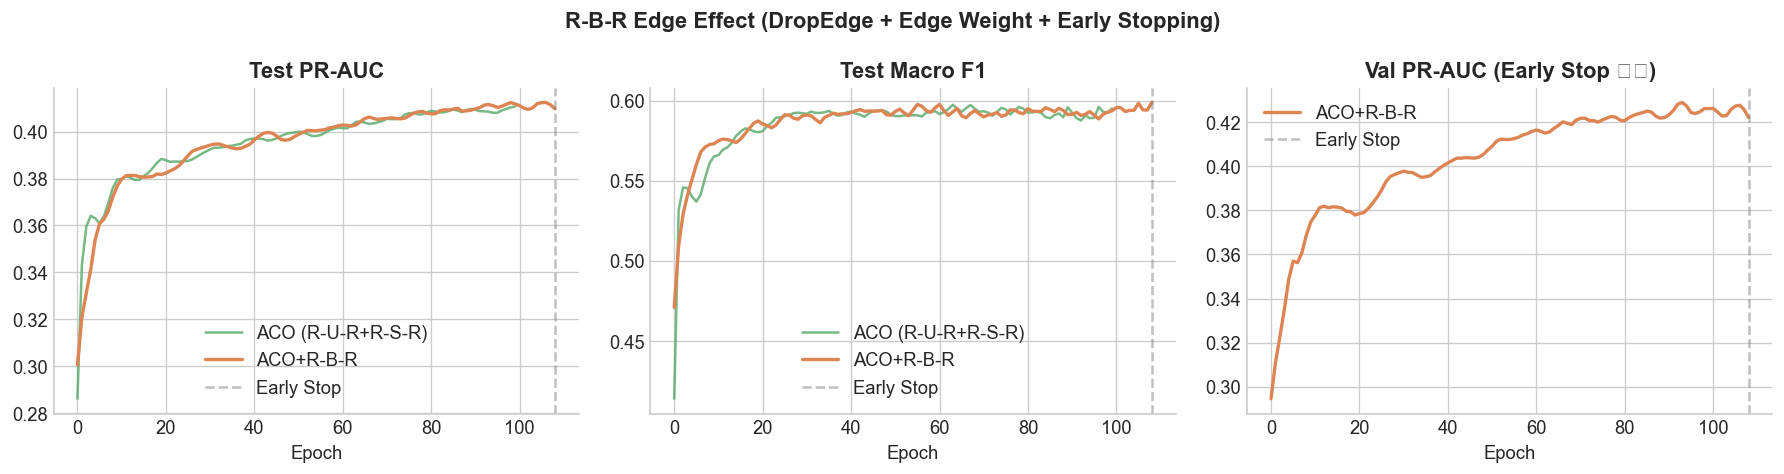


=== Final Performance ===
ACO  (R-U-R+R-S-R)        : PR-AUC=0.4107 | F1=0.5952
ACO + R-B-R (Best model)  : PR-AUC=0.4116 | F1=0.5917


In [58]:
import copy

# ── 처방 2: 엣지 가중치 설계 (R-U-R=1.0, R-S-R=1.0, R-B-R=0.3) ─────────────
n_rur_e = len(rur_src)
n_rsr_e = len(rsr_src)
n_rbr_e = len(rbr_src_u)

ei_rbr = torch.tensor(
    [rur_src + rsr_src + rbr_src_u,
     rur_dst + rsr_dst + rbr_dst_u],
    dtype=torch.long
)
edge_weight_rbr = torch.tensor(
    [1.0] * n_rur_e + [1.0] * n_rsr_e + [1.0] * n_rbr_e,
    dtype=torch.float
).to(DEVICE)

print(f"R-U-R: {n_rur_e//2:,} | R-S-R: {n_rsr_e//2:,} | R-B-R: {n_rbr_e//2:,} | Total: {ei_rbr.shape[1]//2:,}")

# ── 엣지 가중치 지원 GCN ────────────────────────────────────────────────────
class GCN_w(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.dropout(F.relu(self.conv1(x, edge_index, edge_weight)), p=self.drop, training=self.training)
        x = F.dropout(F.relu(self.conv2(x, edge_index, edge_weight)), p=self.drop, training=self.training)
        return self.lin(x)

# ── 처방 3: Train → Train/Val 분리 (Early Stopping용) ───────────────────────
val_size  = int(len(tr_idx) * 0.1)
tr_idx2   = tr_idx[val_size:]
val_idx   = tr_idx[:val_size]
tr_mask2  = torch.zeros(len(sub), dtype=torch.bool); tr_mask2[tr_idx2] = True
val_mask  = torch.zeros(len(sub), dtype=torch.bool); val_mask[val_idx]  = True

X_tensor = torch.tensor(X, dtype=torch.float).to(DEVICE)
y_tensor = torch.tensor(y, dtype=torch.long).to(DEVICE)

# ── 처방 1+3: DropEdge + Early Stopping 학습 ────────────────────────────────
DROPEDGE_RATE = 0.3    # 매 epoch R-B-R 엣지 30% 랜덤 제거
PATIENCE      = 15     # val PR-AUC 개선 없으면 중단
MAX_EPOCHS    = 200

rbr_start = n_rur_e + n_rsr_e   # ei_rbr에서 R-B-R 시작 인덱스

model_rbr  = GCN_w(in_ch=len(feature_cols)).to(DEVICE)
opt_rbr    = torch.optim.Adam(model_rbr.parameters(), lr=0.01, weight_decay=5e-4)
best_val   = -1
best_state = None
p_count    = 0
hist_rbr   = {'loss': [], 'pr_auc': [], 'macro_f1': [], 'val_auc': []}

for ep in range(1, MAX_EPOCHS + 1):
    model_rbr.train(); opt_rbr.zero_grad()

    # DropEdge: R-B-R 엣지만 선택적으로 드롭
    keep = torch.ones(ei_rbr.shape[1], dtype=torch.bool)
    drop_idx = torch.where(torch.rand(n_rbr_e) < DROPEDGE_RATE)[0] + rbr_start
    keep[drop_idx] = False
    ei_drop = ei_rbr[:, keep].to(DEVICE)
    ew_drop = edge_weight_rbr[keep]

    out  = model_rbr(X_tensor, ei_drop, ew_drop)
    loss = F.cross_entropy(out[tr_mask2], y_tensor[tr_mask2], weight=cw)
    loss.backward(); opt_rbr.step()

    # 평가 (전체 엣지 사용)
    model_rbr.eval()
    with torch.no_grad():
        full_out  = model_rbr(X_tensor, ei_rbr.to(DEVICE), edge_weight_rbr)
        prob_all  = F.softmax(full_out, dim=1)[:, 1].cpu().numpy()
        pred_all  = full_out.argmax(dim=1).cpu().numpy()

    val_auc = average_precision_score(y[val_mask.cpu()], prob_all[val_mask.cpu()])
    te_auc  = average_precision_score(y[te_mask.cpu()],  prob_all[te_mask.cpu()])
    te_f1   = f1_score(y[te_mask.cpu()], pred_all[te_mask.cpu()], average='macro', zero_division=0)

    hist_rbr['loss'].append(loss.item())
    hist_rbr['pr_auc'].append(te_auc)
    hist_rbr['macro_f1'].append(te_f1)
    hist_rbr['val_auc'].append(val_auc)

    # Early Stopping (val PR-AUC 기준)
    if val_auc > best_val:
        best_val   = val_auc
        best_state = copy.deepcopy(model_rbr.state_dict())
        p_count    = 0
    else:
        p_count += 1

    if ep % 10 == 0:
        print(f"Epoch {ep:3d} | Loss {loss.item():.4f} | Val {val_auc:.4f} | Test AUC {te_auc:.4f} | F1 {te_f1:.4f} | Pat {p_count}/{PATIENCE}")

    if p_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {ep}  (best val AUC: {best_val:.4f})")
        break

# Best model 복원 후 최종 평가
model_rbr.load_state_dict(best_state)
model_rbr.eval()
with torch.no_grad():
    final_out  = model_rbr(X_tensor, ei_rbr.to(DEVICE), edge_weight_rbr)
    prob_final = F.softmax(final_out, dim=1)[:, 1].cpu().numpy()
    pred_final = final_out.argmax(dim=1).cpu().numpy()

final_auc = average_precision_score(y[te_mask.cpu()], prob_final[te_mask.cpu()])
final_f1  = f1_score(y[te_mask.cpu()], pred_final[te_mask.cpu()], average='macro', zero_division=0)

# 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ['pr_auc', 'macro_f1', 'val_auc'],
                                  ['Test PR-AUC', 'Test Macro F1', 'Val PR-AUC (Early Stop 기준)']):
    if key != 'val_auc':
        ax.plot(hist_ACO[key], label='ACO (R-U-R+R-S-R)', color='#55A868', alpha=0.8)
    ax.plot(hist_rbr[key], label='ACO+R-B-R', color='#DD8452', linewidth=2)
    ax.axvline(len(hist_rbr['loss']) - 1, color='gray', linestyle='--', alpha=0.5, label='Early Stop')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend(frameon=False)
plt.suptitle('R-B-R Edge Effect (DropEdge + Edge Weight + Early Stopping)', fontweight='bold')
plt.tight_layout()
plt.savefig('beam_search_compare.png', bbox_inches='tight')
plt.show()

print("\n=== Final Performance ===")
print(f"ACO  (R-U-R+R-S-R)        : PR-AUC={hist_ACO['pr_auc'][-1]:.4f} | F1={hist_ACO['macro_f1'][-1]:.4f}")
print(f"ACO + R-B-R (Best model)  : PR-AUC={final_auc:.4f} | F1={final_f1:.4f}")

## 5. Louvain 커뮤니티 탐지 — R-C-R 커스텀 엣지

Louvain 알고리즘으로 기존 그래프(R-U-R + R-S-R)의 커뮤니티를 탐지하고, 스팸 밀도가 높은 커뮤니티 내 노드끼리 **R-C-R (Review-Community-Review)** 엣지를 생성한다.

빔서치(확률 기반 경로)와 달리 Louvain은 **구조적 연결성** 기반으로 커뮤니티를 찾는다. 두 방식은 서로 다른 축에서 사기 링을 포착한다.

In [59]:
import networkx as nx

# ── Louvain 커뮤니티 탐지 ─────────────────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(range(len(sub)))
ei_np = ei.cpu().numpy()
G.add_edges_from(zip(ei_np[0], ei_np[1]))

communities = nx.community.louvain_communities(G, seed=42)
print(f"총 커뮤니티 수: {len(communities):,}")

# 커뮤니티별 스팸 비율
comm_stats = [(list(c), np.mean([y[n] for n in c])) for c in communities]
high_spam_comms = [(nodes, sr) for nodes, sr in comm_stats
                   if sr > y.mean() and len(nodes) >= 2]
print(f"고스팸 커뮤니티 (>{y.mean():.2%}): {len(high_spam_comms):,} / {len(communities):,}")

# ── R-C-R 엣지 생성 ────────────────────────────────────────────────────────────
MAX_PER_COMM = 20   # 커뮤니티당 최대 노드 수 (사기 확률 상위)
rcr_src_list, rcr_dst_list = [], []

for nodes, spam_rate in high_spam_comms:
    if len(nodes) > MAX_PER_COMM:
        nodes = sorted(nodes, key=lambda n: fraud_prob[n], reverse=True)[:MAX_PER_COMM]
    for u, v in combinations(nodes, 2):
        rcr_src_list += [u, v]
        rcr_dst_list += [v, u]

rcr_edges_set  = set(zip(rcr_src_list, rcr_dst_list))
rcr_src_u2 = [e[0] for e in rcr_edges_set]
rcr_dst_u2 = [e[1] for e in rcr_edges_set]

print(f"R-C-R edges      : {len(rcr_edges_set) // 2:,}")
if rcr_src_u2:
    rcr_nodes = set(rcr_src_u2)
    rcr_fraud  = np.mean([y[n] for n in rcr_nodes])
    rcr_ratio  = len(rcr_edges_set) / (ei.shape[1] + len(rcr_edges_set)) * 100
    print(f"R-C-R 노드 사기 비율: {rcr_fraud:.2%}  (전체: {y.mean():.2%})")
    print(f"전체 엣지 대비 R-C-R 비중: {rcr_ratio:.1f}%")

총 커뮤니티 수: 25,722
고스팸 커뮤니티 (>18.94%): 672 / 25,722
R-C-R edges      : 27,975
R-C-R 노드 사기 비율: 59.68%  (전체: 18.94%)
전체 엣지 대비 R-C-R 비중: 12.9%


In [60]:
import copy

# ── 공통 학습 함수 ─────────────────────────────────────────────────────────────
DROPEDGE_RATE = 0.3
PATIENCE      = 15
MAX_EPOCHS    = 200

def train_gcn_extra(extra_src, extra_dst, extra_w, name):
    n_extra   = len(extra_src)
    ei_ext    = torch.tensor([rur_src + rsr_src + extra_src,
                               rur_dst + rsr_dst + extra_dst], dtype=torch.long)
    ew_ext    = torch.tensor([1.0]*len(rur_src) + [1.0]*len(rsr_src) +
                              [extra_w]*n_extra, dtype=torch.float).to(DEVICE)
    ext_start = len(rur_src) + len(rsr_src)

    model = GCN_w(in_ch=len(feature_cols)).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    best_val, best_state, p_count = -1, None, 0

    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); opt.zero_grad()
        keep     = torch.ones(ei_ext.shape[1], dtype=torch.bool)
        drop_idx = torch.where(torch.rand(n_extra) < DROPEDGE_RATE)[0] + ext_start
        keep[drop_idx] = False
        out  = model(X_tensor, ei_ext[:, keep].to(DEVICE), ew_ext[keep])
        loss = F.cross_entropy(out[tr_mask2], y_tensor[tr_mask2], weight=cw)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            prob_all = F.softmax(model(X_tensor, ei_ext.to(DEVICE), ew_ext), dim=1)[:, 1].cpu().numpy()
            pred_all = model(X_tensor, ei_ext.to(DEVICE), ew_ext).argmax(dim=1).cpu().numpy()

        val_auc = average_precision_score(y[val_mask.cpu()], prob_all[val_mask.cpu()])
        if val_auc > best_val:
            best_val = val_auc; best_state = copy.deepcopy(model.state_dict()); p_count = 0
        else:
            p_count += 1

        if ep % 10 == 0:
            te_auc = average_precision_score(y[te_mask.cpu()], prob_all[te_mask.cpu()])
            te_f1  = f1_score(y[te_mask.cpu()], pred_all[te_mask.cpu()], average='macro', zero_division=0)
            print(f"Epoch {ep:3d} | Val {val_auc:.4f} | Test {te_auc:.4f} | F1 {te_f1:.4f} | Pat {p_count}/{PATIENCE}")

        if p_count >= PATIENCE:
            print(f"Early stopping at epoch {ep}  (best val: {best_val:.4f})")
            break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        prob_f = F.softmax(model(X_tensor, ei_ext.to(DEVICE), ew_ext), dim=1)[:, 1].cpu().numpy()
        pred_f = model(X_tensor, ei_ext.to(DEVICE), ew_ext).argmax(dim=1).cpu().numpy()
    auc = average_precision_score(y[te_mask.cpu()], prob_f[te_mask.cpu()])
    f1  = f1_score(y[te_mask.cpu()], pred_f[te_mask.cpu()], average='macro', zero_division=0)
    print(f"\n[{name}] PR-AUC={auc:.4f} | F1={f1:.4f}")
    return auc, f1

# ── ACO + R-C-R ───────────────────────────────────────────────────────────────
print("="*50 + "\n  ACO + R-C-R\n" + "="*50)
rcr_auc, rcr_f1 = train_gcn_extra(rcr_src_u2, rcr_dst_u2, 1.0, "ACO + R-C-R")

# ── ACO + R-B-R + R-C-R ───────────────────────────────────────────────────────
print("\n" + "="*50 + "\n  ACO + R-B-R + R-C-R\n" + "="*50)
comb_src = rbr_src_u + rcr_src_u2
comb_dst = rbr_dst_u + rcr_dst_u2
comb_auc, comb_f1 = train_gcn_extra(comb_src, comb_dst, 1.0, "ACO + R-B-R + R-C-R")

# ── 최종 비교 ─────────────────────────────────────────────────────────────────
print("\n=== Final Comparison ===")
print(f"ACO only            : PR-AUC={hist_ACO['pr_auc'][-1]:.4f} | F1={hist_ACO['macro_f1'][-1]:.4f}")
print(f"ACO + R-B-R         : PR-AUC={final_auc:.4f} | F1={final_f1:.4f}")
print(f"ACO + R-C-R         : PR-AUC={rcr_auc:.4f} | F1={rcr_f1:.4f}")
print(f"ACO + R-B-R + R-C-R : PR-AUC={comb_auc:.4f} | F1={comb_f1:.4f}")

  ACO + R-C-R
Epoch  10 | Val 0.3690 | Test 0.3674 | F1 0.5607 | Pat 0/15
Epoch  20 | Val 0.3754 | Test 0.3784 | F1 0.5773 | Pat 4/15
Epoch  30 | Val 0.3936 | Test 0.3890 | F1 0.5809 | Pat 0/15
Epoch  40 | Val 0.4045 | Test 0.3930 | F1 0.5844 | Pat 0/15
Epoch  50 | Val 0.4082 | Test 0.3940 | F1 0.5848 | Pat 3/15
Epoch  60 | Val 0.4124 | Test 0.3977 | F1 0.5896 | Pat 1/15
Epoch  70 | Val 0.4140 | Test 0.3993 | F1 0.5875 | Pat 6/15
Epoch  80 | Val 0.4175 | Test 0.4011 | F1 0.5890 | Pat 2/15
Epoch  90 | Val 0.4161 | Test 0.4015 | F1 0.5926 | Pat 6/15
Epoch 100 | Val 0.4194 | Test 0.4027 | F1 0.5856 | Pat 3/15
Epoch 110 | Val 0.4168 | Test 0.4028 | F1 0.5849 | Pat 3/15
Epoch 120 | Val 0.4189 | Test 0.4005 | F1 0.5949 | Pat 4/15
Epoch 130 | Val 0.4228 | Test 0.4046 | F1 0.5870 | Pat 3/15
Epoch 140 | Val 0.4213 | Test 0.4056 | F1 0.5903 | Pat 13/15
Epoch 150 | Val 0.4225 | Test 0.4042 | F1 0.5850 | Pat 7/15
Early stopping at epoch 158  (best val: 0.4269)

[ACO + R-C-R] PR-AUC=0.4082 | F1=0.5

In [ ]:
# ── R-T-R: 같은 상품, N일 이내 리뷰 연결 ────────────────────────────────────
N_DAYS = 3

rtr_pairs = set()
for _, group in sub.groupby('prod_id'):
    grp = group.sort_values('date')[['node_id', 'date']].values
    for i in range(len(grp)):
        for j in range(i + 1, len(grp)):
            diff = (grp[j][1] - grp[i][1]).days
            if diff <= N_DAYS:
                u, v = int(grp[i][0]), int(grp[j][0])
                rtr_pairs.add((min(u, v), max(u, v)))
            else:
                break

rtr_src_u = [e for p in rtr_pairs for e in [p[0], p[1]]]
rtr_dst_u = [e for p in rtr_pairs for e in [p[1], p[0]]]
rtr_fraud  = np.mean([y[n] for n in set(rtr_src_u)]) if rtr_src_u else 0
print(f"R-T-R edges      : {len(rtr_pairs):,}  |  노드 사기 비율: {rtr_fraud:.2%}")

# ── R-D-R: 공통 이웃을 공유하는 고사기 노드쌍 직접 연결 ─────────────────────
FRAUD_THRESH_RDR = np.percentile(fraud_prob, 80)  # 상위 20%

node_nbrs = defaultdict(set)
for s, d in zip(ei_np[0], ei_np[1]):
    node_nbrs[s].add(d)

rdr_pairs = set()
for node in range(len(sub)):
    hf_nbrs = [n for n in node_nbrs[node] if fraud_prob[n] >= FRAUD_THRESH_RDR]
    if len(hf_nbrs) >= 2:
        for i in range(len(hf_nbrs)):
            for j in range(i + 1, len(hf_nbrs)):
                u, v = hf_nbrs[i], hf_nbrs[j]
                rdr_pairs.add((min(u, v), max(u, v)))

rdr_src_u = [e for p in rdr_pairs for e in [p[0], p[1]]]
rdr_dst_u = [e for p in rdr_pairs for e in [p[1], p[0]]]
rdr_fraud  = np.mean([y[n] for n in set(rdr_src_u)]) if rdr_src_u else 0
print(f"R-D-R edges      : {len(rdr_pairs):,}  |  노드 사기 비율: {rdr_fraud:.2%}")

# ── 조합 실험 ─────────────────────────────────────────────────────────────────
results = {}

configs = [
    ("ACO + R-T-R",             rtr_src_u, rtr_dst_u),
    ("ACO + R-D-R",             rdr_src_u, rdr_dst_u),
    ("ACO + R-B-R + R-T-R",    rbr_src_u + rtr_src_u, rbr_dst_u + rtr_dst_u),
    ("ACO + R-B-R + R-D-R",    rbr_src_u + rdr_src_u, rbr_dst_u + rdr_dst_u),
    ("ACO + R-T-R + R-D-R",    rtr_src_u + rdr_src_u, rtr_dst_u + rdr_dst_u),
    ("ACO + R-B-R + R-T-R + R-D-R", rbr_src_u + rtr_src_u + rdr_src_u,
                                      rbr_dst_u + rtr_dst_u + rdr_dst_u),
]

for name, src, dst in configs:
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    auc, f1 = train_gcn_extra(src, dst, 1.0, name)
    results[name] = (auc, f1)

print("\n=== Final Comparison ===")
print(f"ACO only            : PR-AUC={hist_ACO['pr_auc'][-1]:.4f} | F1={hist_ACO['macro_f1'][-1]:.4f}")
print(f"ACO + R-B-R         : PR-AUC={final_auc:.4f} | F1={final_f1:.4f}")
for name, (auc, f1) in results.items():
    print(f"{name:35s}: PR-AUC={auc:.4f} | F1={f1:.4f}")